In [1]:
!nvidia-smi

Tue Apr 14 17:21:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install pycuda pillow numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.4 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=a3894ad491c12470a07e9c5c2f978609a205f805d4ee1adaf335163c08050d8c
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import ctypes, ctypes.util


## 1. Загрузка и подготовка изображения

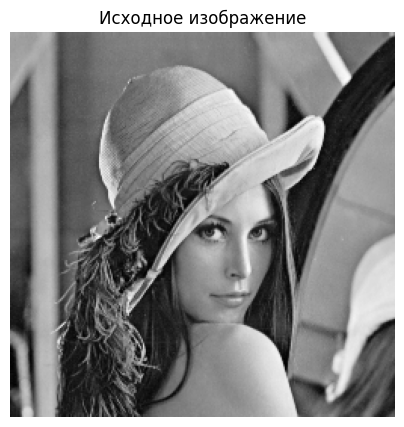

Размер: (255, 255)


In [4]:
image_path = "image.bmp"
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Файл {image_path} не найден.")
gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_image = cv2.resize(gray_image, (255, 255))
plt.figure(figsize=(5,5))
plt.imshow(gray_image, cmap='gray'); plt.axis('off')
plt.title('Исходное изображение'); plt.show()
print("Размер:", gray_image.shape)


## 2. Добавление шума «соль и перец»

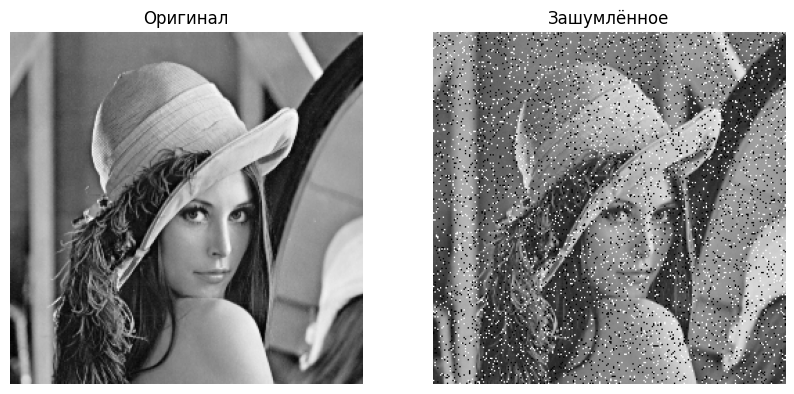

In [5]:
def add_salt_pepper_noise(image, prob=0.1):
    noisy = np.copy(image)
    rnd = np.random.random(image.shape)
    noisy[rnd < prob / 2] = 0
    noisy[(rnd >= prob / 2) & (rnd < prob)] = 255
    return noisy

noisy_image = add_salt_pepper_noise(gray_image, prob=0.1)
Image.fromarray(noisy_image).save('input_image.bmp')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray_image, cmap='gray')
plt.title('Оригинал'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(noisy_image, cmap='gray')
plt.title('Зашумлённое'); plt.axis('off')
plt.show()


## 3. CUDA-ядро медианного фильтра


In [10]:
FILTER_CODE = '\n#include <cuda_runtime.h>\n#include <stdint.h>\n\nextern "C"\n__global__ void median_filter_texture(\n    unsigned long long tex_handle,\n    unsigned char *output,\n    int width,\n    int height)\n{\n    int x = blockIdx.x * blockDim.x + threadIdx.x;\n    int y = blockIdx.y * blockDim.y + threadIdx.y;\n    if (x >= width || y >= height) return;\n\n    cudaTextureObject_t texObj = (cudaTextureObject_t)tex_handle;\n\n    unsigned char neighbors[9];\n    int idx = 0;\n    for (int dy = -1; dy <= 1; dy++) {\n        for (int dx = -1; dx <= 1; dx++) {\n            int nx = min(max(x + dx, 0), width - 1);\n            int ny = min(max(y + dy, 0), height - 1);\n            neighbors[idx++] = tex2D<unsigned char>(texObj, nx, ny);\n        }\n    }\n\n    // Сортировка пузырьком\n    for (int i = 0; i < 9; i++)\n        for (int j = 0; j < 9 - i - 1; j++)\n            if (neighbors[j] > neighbors[j+1]) {\n                unsigned char tmp = neighbors[j];\n                neighbors[j]   = neighbors[j+1];\n                neighbors[j+1] = tmp;\n            }\n\n    output[y * width + x] = neighbors[4];\n}\n'

mod = SourceModule(FILTER_CODE)
median_kernel = mod.get_function('median_filter_texture')


## 4. Создание Texture Object

In [11]:

libcudart = ctypes.CDLL('libcudart.so', mode=ctypes.RTLD_GLOBAL)

# --- Структуры CUDA Runtime API ---
class cudaChannelFormatDesc(ctypes.Structure):
    _fields_ = [
        ('x', ctypes.c_int),
        ('y', ctypes.c_int),
        ('z', ctypes.c_int),
        ('w', ctypes.c_int),
        ('f', ctypes.c_int),  # cudaChannelFormatKindUnsigned = 2
    ]

class cudaResourceDesc(ctypes.Structure):
    _fields_ = [
        ('resType',   ctypes.c_int),      # cudaResourceTypeArray = 0
        ('array',     ctypes.c_void_p),   # cudaArray_t
        ('_pad',      ctypes.c_uint8 * 56),
    ]

class cudaTextureDesc(ctypes.Structure):
    _fields_ = [
        ('addressMode',        ctypes.c_int * 3),   # CLAMP=1
        ('filterMode',         ctypes.c_int),        # POINT=0
        ('readMode',           ctypes.c_int),        # ElementType=0
        ('sRGB',               ctypes.c_int),
        ('borderColor',        ctypes.c_float * 4),
        ('normalizedCoords',   ctypes.c_int),
        ('maxAnisotropy',      ctypes.c_uint),
        ('mipmapFilterMode',   ctypes.c_int),
        ('mipmapLevelBias',    ctypes.c_float),
        ('minMipmapLevelClamp',ctypes.c_float),
        ('maxMipmapLevelClamp',ctypes.c_float),
        ('disableTrilinearOptimization', ctypes.c_int),
        ('seamlessCubemap',    ctypes.c_int),
    ]

def create_texture_object(cuda_array):

    resDesc = cudaResourceDesc()
    ctypes.memset(ctypes.addressof(resDesc), 0, ctypes.sizeof(resDesc))
    resDesc.resType = 0
    resDesc.array   = cuda_array.handle

    texDesc = cudaTextureDesc()
    ctypes.memset(ctypes.addressof(texDesc), 0, ctypes.sizeof(texDesc))
    texDesc.addressMode[0]  = 1
    texDesc.addressMode[1]  = 1
    texDesc.filterMode      = 0
    texDesc.readMode        = 0
    texDesc.normalizedCoords = 0

    tex_obj = ctypes.c_uint64(0)
    ret = libcudart.cudaCreateTextureObject(
        ctypes.byref(tex_obj),
        ctypes.byref(resDesc),
        ctypes.byref(texDesc),
        None
    )
    if ret != 0:
        raise RuntimeError(f"cudaCreateTextureObject failed: {ret}")
    return tex_obj.value




## 5. Применение медианного фильтра

In [8]:
def apply_median_filter_texture(image_path, output_path):
    image = Image.open(image_path).convert('L')
    image_data = np.array(image, dtype=np.uint8)
    height, width = image_data.shape


    descr = cuda.ArrayDescriptor()
    descr.width        = width
    descr.height       = height
    descr.format       = cuda.array_format.UNSIGNED_INT8
    descr.num_channels = 1
    cuda_array = cuda.Array(descr)

    copy2d = cuda.Memcpy2D()
    copy2d.set_src_host(image_data)
    copy2d.set_dst_array(cuda_array)
    copy2d.width_in_bytes = width
    copy2d.src_pitch      = width
    copy2d.height         = height
    copy2d(aligned=True)


    tex_handle = create_texture_object(cuda_array)
    print(f"Texture object handle: {tex_handle}")


    output_data = np.empty_like(image_data)
    output_gpu  = cuda.mem_alloc(image_data.nbytes)

    block_size = (16, 16, 1)
    grid_size  = (
        (width  + block_size[0] - 1) // block_size[0],
        (height + block_size[1] - 1) // block_size[1],
    )

    # Замер времени через CUDA Events
    start_evt = cuda.Event()
    stop_evt  = cuda.Event()
    start_evt.record()

    median_kernel(
        np.uint64(tex_handle),
        output_gpu,
        np.int32(width),
        np.int32(height),
        block=block_size,
        grid=grid_size,
    )

    stop_evt.record()
    stop_evt.synchronize()

    gpu_time_ms = stop_evt.time_since(start_evt)

    cuda.memcpy_dtoh(output_data, output_gpu)
    Image.fromarray(output_data).save(output_path)


    libcudart.cudaDestroyTextureObject(ctypes.c_uint64(tex_handle))

    print(f"Время обработки на GPU: {gpu_time_ms:.3f} мс ({gpu_time_ms/1000:.6f} с)")
    print(f"Результат сохранён: {output_path}")
    return image_data, output_data, gpu_time_ms


input_data, output_data, gpu_time_ms = apply_median_filter_texture(
    'input_image.bmp',
    'output_image.bmp'
)


Texture object handle: 1
Время обработки на GPU: 0.609 мс (0.000609 с)
Результат сохранён: output_image.bmp


## 6. Визуализация результатов

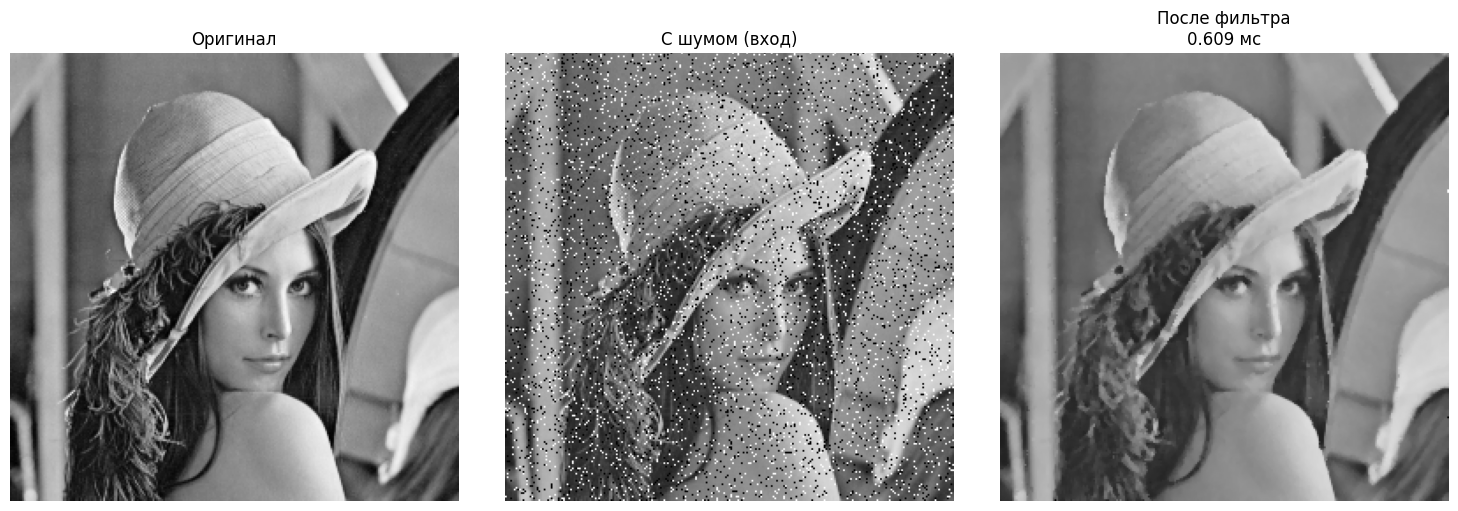

Размер: 255x255 пикс.
Время GPU: 0.609 мс


In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Оригинал'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(input_data, cmap='gray')
plt.title('С шумом (вход)'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(output_data, cmap='gray')
plt.title(f'После фильтра\n{gpu_time_ms:.3f} мс'); plt.axis('off')

plt.tight_layout(); plt.show()
print(f"Размер: {input_data.shape[1]}x{input_data.shape[0]} пикс.")
print(f"Время GPU: {gpu_time_ms:.3f} мс")
